In [1]:
install.packages("censusapi")
options(scipen = 0, digits = 3)  ## controls base R output

## Package setup
if(!require("pacman")) install.packages("pacman")

pacman::p_load(tidyverse, dplyr, ggplot2, data.table, lubridate,
               plotROC, usmap, glmnet, car, tidycensus, broom, purrr, readr)

trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/censusapi_0.10.0.tgz'
Content type 'application/x-gzip' length 68818 bytes (67 KB)
downloaded 67 KB




The downloaded binary packages are in
	/var/folders/cv/nclv9trn34gfwv31czswr2jw0000gp/T//RtmptjoV7N/downloaded_packages
Loading required package: pacman


In [2]:
census_api_key("7c021914c63b3bbf8ac70b7e38e2fa44e98f64d9", install = TRUE, overwrite = TRUE)

# Force the current session to read the environment file you just updated
readRenviron("~/.Renviron")

Your original .Renviron will be backed up and stored in your R HOME directory if needed.
Your API key has been stored in your .Renviron and can be accessed by Sys.getenv("CENSUS_API_KEY"). 
To use now, restart R or run `readRenviron("~/.Renviron")`


In [3]:
files <- c(
  "data/GDPData/GDP2006-2003.csv",
  "data/GDPData/GDP2012-2007.csv",
  "data/GDPData/GDP2019-2013.csv",
  "data/GDPData/GDP2025-2020.csv"
)

# 2. Read the files into a list of dataframes, skipping the 3 title rows BEA uses
df_list <- map(files, ~read_csv(.x, skip = 3, show_col_types = FALSE))

# 3. Merge them: left_join all files on the geographic identifiers.
#    Note the column is GeoFIPS (all-caps IPS), not GeoFips.
master_df <- df_list %>%
  reduce(left_join, by = c("GeoFIPS", "GeoName")) %>%
  # BEA's footnote lines at the bottom have no GeoName, so drop rows missing it
  filter(!is.na(GeoName))

# 4. Export the combined data to a master CSV file
write_csv(master_df, "NFL_Cities_GDP_Master_2003_2025.csv")

cat("Master CSV created successfully in your working directory!")


Warning messages:
1: One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 
2: One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 
3: One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 
4: One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 


Master CSV created successfully in your working directory!

In [4]:
packageVersion("censusapi")

[1] ‘0.10.0’

In [5]:
sessionInfo()
packageVersion("censusapi")

[1] ‘0.10.0’

In [6]:
# target_state <- "TX"
# target_city <- "Austin city"

# ## Part 1: Social & Demographic Data (via tidycensus)

# # 1. Explicitly define the raw Census codes here
# acs_vars <- c(
#   "B19013_001", # Median household income
#   "B23025_002", # Total labor force
#   "B23025_005", # Unemployed
#   "B25003_001", # Total housing units
#   "B25003_002", # Owner-occupied units
#   "B25077_001"  # Median property value
# )

# # 2. Fetch the data
# city_acs_data <- get_acs(
#   geography = "place",
#   state     = target_state,
#   variables = acs_vars,
#   year      = 2022, 
#   output    = "wide"
# ) %>%
#   filter(str_detect(NAME, target_city)) %>%
#   # 3. Calculate custom rates using the raw code headers + E
#   mutate(
#     unemployment_rate = (B23025_005E / B23025_002E) * 100,
#     homeownership_rate = (B25003_002E / B25003_001E) * 100
#   ) %>%
#   # 4. Clean up and rename the final columns
#   select(
#     NAME, 
#     median_household_income = B19013_001E, 
#     homeownership_rate, 
#     median_property_value   = B25077_001E,
#     unemployment_rate
#   )

# print("--- ACS City Data ---")
# print(city_acs_data)


# ## Part 2: Business & Economic Data (via censusapi)

# # Fetch 2022 County Business Patterns for Travis County
# travis_county_cbp <- censusapi::getCensus(
#   name = "cbp",
#   vintage = 2022,
#   vars = c("ESTAB", "EMP", "PAYANN", "NAICS2017"),
#   region = "county:*",
#   regionin = "state:48"
# ) %>%
#   filter(county == "453")

# # Clean and view industry statistics
# city_business_data <- travis_county_cbp %>%
#   rename(
#     establishments = ESTAB,
#     employees = EMP,
#     annual_payroll_thousands = PAYANN,
#     naics_code = NAICS2017
#   ) %>%
#   filter(naics_code != "00")

# print("--- County Business Patterns Data ---")
# head(city_business_data)

In [7]:
## Part 3: Quality-of-Life Census Data for ALL Pro Sports Metro Areas
## Generalizes Part 1 above from a single city (Austin) to every metro
## area in sports_teams_lookup.csv that has at least one pro sports team.
## NHL is excluded from scope, so metros whose only team is NHL (e.g. San
## Jose Sharks, Columbus Blue Jackets) are not included here.

# 1. Load the lookup table and keep only metro areas with an NFL/NBA/MLB team
sports_teams <- read_csv("data/sports_teams_lookup.csv") %>%
  mutate(GEOID = as.character(GEOID))

pro_sports_metros <- sports_teams %>%
  filter(has_NFL == 1 | has_NBA == 1 | has_MLB == 1)

cat(nrow(pro_sports_metros), "metro areas have an NFL, NBA, or MLB team\n")

# 2. Define the ACS variables we want for each metro area
qol_vars <- c(
  median_household_income = "B19013_001", # income
  labor_force             = "B23025_002", # for unemployment rate
  unemployed              = "B23025_005", # for unemployment rate
  median_home_value       = "B25077_001", # land/property value
  median_gross_rent       = "B25064_001", # housing cost burden
  housing_units           = "B25003_001", # for homeownership rate
  owner_occupied          = "B25003_002", # for homeownership rate
  poverty_universe        = "B17001_001", # for poverty rate
  below_poverty           = "B17001_002", # for poverty rate
  edu_universe_25plus     = "B15003_001", # for bachelor's+ attainment
  edu_bachelors           = "B15003_022",
  edu_masters             = "B15003_023",
  edu_professional        = "B15003_024",
  edu_doctorate           = "B15003_025"
)

# 3. Pull ACS 5-year data for ALL CBSAs in a single API call (much cheaper
#    than one call per metro), then filter down to the pro sports metros
all_cbsa_acs <- get_acs(
  geography = "cbsa",
  variables = qol_vars,
  year      = 2022,
  survey    = "acs5",
  output    = "wide"
)

# 4. Join sports info onto the census data and compute quality-of-life rates
metro_qol_data <- all_cbsa_acs %>%
  filter(GEOID %in% pro_sports_metros$GEOID) %>%
  left_join(
    pro_sports_metros %>%
      select(GEOID, team_count, has_NFL, has_NBA, has_MLB, has_NHL),
    by = "GEOID"
  ) %>%
  mutate(
    unemployment_rate   = unemployedE / labor_forceE * 100,
    homeownership_rate  = owner_occupiedE / housing_unitsE * 100,
    poverty_rate        = below_povertyE / poverty_universeE * 100,
    bachelors_plus_rate = (edu_bachelorsE + edu_mastersE + edu_professionalE + edu_doctorateE) /
                            edu_universe_25plusE * 100
  ) %>%
  select(
    GEOID, NAME,
    team_count, has_NFL, has_NBA, has_MLB, has_NHL,
    median_household_income = median_household_incomeE,
    median_home_value       = median_home_valueE,
    median_gross_rent       = median_gross_rentE,
    unemployment_rate,
    homeownership_rate,
    poverty_rate,
    bachelors_plus_rate
  ) %>%
  arrange(desc(team_count))

print(sprintf("Fetched quality-of-life data for %d / %d pro sports metro areas",
              nrow(metro_qol_data), nrow(pro_sports_metros)))

# 5. Flag any metros from the lookup table that didn't match a CBSA in the pull
missing_metros <- pro_sports_metros %>% filter(!GEOID %in% metro_qol_data$GEOID)
if (nrow(missing_metros) > 0) {
  print("--- Metro areas with no matching ACS data (check GEOID) ---")
  print(missing_metros %>% select(GEOID, NAME))
}

print("--- Quality of Life Data: Pro Sports Metro Areas ---")
print(metro_qol_data)

Rows: 387 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): NAME
dbl (7): GEOID, team_count, has_NFL, has_NBA, has_MLB, has_NHL, has_team

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
40 metro areas have an NFL, NBA, or MLB team
Getting data from the 2018-2022 5-year ACS
[1] "Fetched quality-of-life data for 39 / 40 pro sports metro areas"
[1] "--- Metro areas with no matching ACS data (check GEOID) ---"
# A tibble: 1 × 2
  GEOID NAME                    
  <chr> <chr>                   
1 17410 Cleveland, OH Metro Area
[1] "--- Quality of Life Data: Pro Sports Metro Areas ---"
# A tibble: 39 × 14
   GEOID NAME  team_count has_NFL has_NBA has_MLB has_NHL median_household_inc…¹
   <chr> <chr>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>                  <dbl>
 1 35620 New …          9       1       1       1       1  

In [8]:
names(metro_qol_data)

 [1] "GEOID"                   "NAME"                   
 [3] "team_count"              "has_NFL"                
 [5] "has_NBA"                 "has_MLB"                
 [7] "has_NHL"                 "median_household_income"
 [9] "median_home_value"       "median_gross_rent"      
[11] "unemployment_rate"       "homeownership_rate"     
[13] "poverty_rate"            "bachelors_plus_rate"    

In [9]:
str(metro_qol_data)

tibble [39 × 14] (S3: tbl_df/tbl/data.frame)
 $ GEOID                  : chr [1:39] "35620" "31080" "16980" "14460" ...
 $ NAME                   : chr [1:39] "New York-Newark-Jersey City, NY-NJ-PA Metro Area" "Los Angeles-Long Beach-Anaheim, CA Metro Area" "Chicago-Naperville-Elgin, IL-IN-WI Metro Area" "Boston-Cambridge-Newton, MA-NH Metro Area" ...
 $ team_count             : num [1:39] 9 8 5 4 4 4 4 4 4 4 ...
 $ has_NFL                : num [1:39] 1 1 1 1 1 1 1 1 1 1 ...
 $ has_NBA                : num [1:39] 1 1 1 1 1 1 1 1 1 1 ...
 $ has_MLB                : num [1:39] 1 1 1 1 1 1 1 1 1 1 ...
 $ has_NHL                : num [1:39] 1 1 1 1 1 1 1 1 1 1 ...
 $ median_household_income: num [1:39] 93610 89105 85087 107117 83398 ...
 $ median_home_value      : num [1:39] 553500 772000 288400 570000 299000 ...
 $ median_gross_rent      : num [1:39] 1711 1892 1310 1827 1409 ...
 $ unemployment_rate      : num [1:39] 6.54 6.58 6.18 5.01 4.62 ...
 $ homeownership_rate     : num [1:39] 51.7

In [10]:
## Part 4: Multi-Year Census Panel for the Pro Sports Metro Areas
## Repeats the Part 3 pull across many ACS 5-year vintages so we have a
## time series of quality-of-life markers per metro, not just one snapshot.
## (ACS 5-year detailed tables like these only go back to the 2009 vintage,
## so seasons before ~2010 in team_stats_2003_2023.csv won't have a match.)

acs_years <- 2010:2023
multi_year_cbsa_acs <- map_dfr(acs_years, function(yr) {
  tryCatch({
    get_acs(
      geography = "cbsa",
      variables = qol_vars,
      year      = yr,
      survey    = "acs5",
      output    = "wide"
    ) %>%
      mutate(year = yr)
  }, error = function(e) {
    # Some variable codes in qol_vars aren't defined for every ACS vintage
    # (tables get renumbered/retired). Skip that year instead of failing
    # the whole loop, and surface which year/variable broke.
    message(sprintf("Skipping %d: %s", yr, conditionMessage(e)))
    tibble()
  })
})

fetched_years <- sort(unique(multi_year_cbsa_acs$year))
skipped_years <- setdiff(acs_years, fetched_years)
if (length(skipped_years) > 0) {
  print("--- Years skipped due to unavailable variables (see messages above) ---")
  print(skipped_years)
}

multi_year_qol_data <- multi_year_cbsa_acs %>%
  filter(GEOID %in% pro_sports_metros$GEOID) %>%
  left_join(
    pro_sports_metros %>%
      select(GEOID, team_count, has_NFL, has_NBA, has_MLB, has_NHL),
    by = "GEOID"
  ) %>%
  mutate(
    unemployment_rate   = unemployedE / labor_forceE * 100,
    homeownership_rate  = owner_occupiedE / housing_unitsE * 100,
    poverty_rate        = below_povertyE / poverty_universeE * 100,
    bachelors_plus_rate = (edu_bachelorsE + edu_mastersE + edu_professionalE + edu_doctorateE) /
                            edu_universe_25plusE * 100
  ) %>%
  select(
    year, GEOID, NAME,
    team_count, has_NFL, has_NBA, has_MLB, has_NHL,
    median_household_income = median_household_incomeE,
    median_home_value       = median_home_valueE,
    median_gross_rent       = median_gross_rentE,
    unemployment_rate,
    homeownership_rate,
    poverty_rate,
    bachelors_plus_rate
  )

print(sprintf("Census panel: %d metro-year rows across %d years (%d-%d)",
              nrow(multi_year_qol_data), length(fetched_years),
              min(acs_years), max(acs_years)))

Getting data from the 2006-2010 5-year ACS
Skipping 2010: Your API call has errors.  The API message returned is error: unknown variable 'B23025_002E'.
Getting data from the 2007-2011 5-year ACS
Skipping 2011: Your API call has errors.  The API message returned is error: unknown variable 'B15003_001E'.
Getting data from the 2008-2012 5-year ACS
Getting data from the 2009-2013 5-year ACS
Getting data from the 2010-2014 5-year ACS
Getting data from the 2011-2015 5-year ACS
Getting data from the 2012-2016 5-year ACS
Getting data from the 2013-2017 5-year ACS
Getting data from the 2014-2018 5-year ACS
Getting data from the 2015-2019 5-year ACS
Getting data from the 2016-2020 5-year ACS
Getting data from the 2017-2021 5-year ACS
Getting data from the 2018-2022 5-year ACS
Getting data from the 2019-2023 5-year ACS
[1] "--- Years skipped due to unavailable variables (see messages above) ---"
[1] 2010 2011
[1] "Census panel: 468 metro-year rows across 12 years (2010-2023)"


In [11]:
## Part 4.5: Add Crime Data to the Metro-Year Census Panel
## sports_metro_crime_2015_2024_metro_agg.csv reports crime by short metro
## name (e.g. "Atlanta") rather than by CBSA GEOID, so we need our own
## name -> GEOID crosswalk before we can join it onto multi_year_qol_data.
crime_metro_geoid <- tribble(
  ~Metro,                     ~GEOID,
  "Atlanta",                  "12060",
  "Baltimore",                "12580",
  "Boston",                   "14460",
  "Buffalo",                  "15380",
  "Charlotte",                "16740",
  "Chicago",                  "16980",
  "Cincinnati",               "17140",
  "Cleveland",                "17410",
  "Columbus",                 "18140",
  "Dallas-Fort Worth",        "19100",
  "Denver",                   "19740",
  "Detroit",                  "19820",
  "Green Bay",                "24580",
  "Houston",                  "26420",
  "Indianapolis",             "26900",
  "Jacksonville",             "27260",
  "Kansas City",              "28140",
  "Las Vegas",                "29820",
  "Los Angeles",              "31080",
  "Memphis",                  "32820",
  "Miami / Fort Lauderdale",  "33100",
  "Milwaukee",                "33340",
  "Minneapolis-St. Paul",     "33460",
  "Nashville",                "34980",
  "New Orleans",              "35380",
  "New York / New Jersey",    "35620",
  "Oklahoma City",            "36420",
  "Orlando",                  "36740",
  "Philadelphia",             "37980",
  "Phoenix",                  "38060",
  "Pittsburgh",               "38300",
  "Portland",                 "38900",
  "Sacramento",               "40900",
  "Salt Lake City",           "41620",
  "San Antonio",              "41700",
  "San Diego",                "41740",
  "San Francisco Bay Area",   "41860",
  "Seattle",                  "42660",
  "St. Louis",                "41180",
  "Tampa Bay",                "45300",
  "Washington, DC",           "47900"
)
# Austin and Raleigh appear in the crime file but have no pro sports team
# (has_team == 0 in sports_teams_lookup.csv), so they're left out on purpose.

crime_raw <- read_csv("data/sports_metro_crime_2015_2024_metro_agg.csv") %>%
  mutate(Metro = str_replace_all(Metro, "[–—]", "-"))  # normalize en/em dashes

# Keep only the violent/property crime totals - the underlying offense
# categories (murder, rape, robbery, ... ) sum exactly to these totals, so
# including both causes perfect collinearity in the regression models below.
crime_data <- crime_raw %>%
  inner_join(crime_metro_geoid, by = "Metro") %>%
  rename(
    year           = Year,
    violent_crime  = `Violent Crime`,
    property_crime = `Property Crime`
  ) %>%
  select(year, GEOID, violent_crime, property_crime)

# Verify every pro sports metro area is represented in the crime data BEFORE
# merging it into the model dataframe - stop and surface the gap if not,
# rather than silently building an incomplete master dataframe.
missing_crime_metros <- pro_sports_metros %>% filter(!GEOID %in% crime_data$GEOID)
if (nrow(missing_crime_metros) > 0) {
  print("--- Pro sports metro areas missing from the crime data ---")
  print(missing_crime_metros %>% select(GEOID, NAME))
  stop("Crime data does not cover all pro sports metro areas - see missing metros above before merging into the model dataframe.")
}

multi_year_qol_data <- multi_year_qol_data %>%
  left_join(crime_data, by = c("year", "GEOID"))

# Crime coverage doesn't extend before 2015 and some metro-years are missing
# even after that (most notably 2021's nationwide UCR->NIBRS reporting gap).
# Drop those incomplete rows from the panel for now rather than imputing.
crime_cols <- c("violent_crime", "property_crime")
rows_before_drop <- nrow(multi_year_qol_data)

multi_year_qol_data <- multi_year_qol_data %>%
  drop_na(all_of(crime_cols))

print(sprintf(
  "Census + crime panel: %d metro-year rows (dropped %d with missing crime data), %d crime variables added",
  nrow(multi_year_qol_data), rows_before_drop - nrow(multi_year_qol_data), length(crime_cols)
))

Rows: 387 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): Metro, Included_Cities, Coverage_Note
dbl (15): Year, Number_of_Cities_Reported, Population_Sum, Violent Crime, Mu...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
[1] "Census + crime panel: 315 metro-year rows (dropped 153 with missing crime data), 2 crime variables added"


In [14]:
## Part 5: Combine Census Panel with NFL Win Percentage
## team_stats_2003_2023.csv has one row per team-season with a franchise
## name (e.g. "Oakland Raiders" vs "Las Vegas Raiders"), but our census data
## is keyed by metro-area GEOID. We need a team -> home-metro GEOID map to
## join the two. Franchises that relocated (Rams, Chargers, Raiders) show up
## under different names for different eras, so a single static name->GEOID
## table is enough - no year-conditional logic needed.
nfl_team_metro_lookup <- tribble(
  ~team,                      ~GEOID,
  "Arizona Cardinals",        "38060", # Phoenix-Mesa-Chandler, AZ
  "Atlanta Falcons",          "12060", # Atlanta-Sandy Springs-Roswell, GA
  "Baltimore Ravens",         "12580", # Baltimore-Columbia-Towson, MD
  "Buffalo Bills",            "15380", # Buffalo-Cheektowaga, NY
  "Carolina Panthers",        "16740", # Charlotte-Concord-Gastonia, NC-SC
  "Chicago Bears",            "16980", # Chicago-Naperville-Elgin, IL-IN
  "Cincinnati Bengals",       "17140", # Cincinnati, OH-KY-IN
  "Cleveland Browns",         "17410", # Cleveland, OH
  "Dallas Cowboys",           "19100", # Dallas-Fort Worth-Arlington, TX
  "Denver Broncos",           "19740", # Denver-Aurora-Centennial, CO
  "Detroit Lions",            "19820", # Detroit-Warren-Dearborn, MI
  "Green Bay Packers",        "24580", # Green Bay, WI
  "Houston Texans",           "26420", # Houston-Pasadena-The Woodlands, TX
  "Indianapolis Colts",       "26900", # Indianapolis-Carmel-Greenwood, IN
  "Jacksonville Jaguars",     "27260", # Jacksonville, FL
  "Kansas City Chiefs",       "28140", # Kansas City, MO-KS
  "Las Vegas Raiders",        "29820", # Las Vegas-Henderson-North Las Vegas, NV (2020+)
  "Oakland Raiders",          "41860", # San Francisco-Oakland-Fremont, CA (pre-2020)
  "Los Angeles Chargers",     "31080", # Los Angeles-Long Beach-Anaheim, CA (2017+)
  "San Diego Chargers",       "41740", # San Diego-Chula Vista-Carlsbad, CA (pre-2017)
  "Los Angeles Rams",         "31080", # Los Angeles-Long Beach-Anaheim, CA (2016+)
  "St. Louis Rams",           "41180", # St. Louis, MO-IL (pre-2016)
  "Miami Dolphins",           "33100", # Miami-Fort Lauderdale-West Palm Beach, FL
  "Minnesota Vikings",        "33460", # Minneapolis-St. Paul-Bloomington, MN-WI
  "New England Patriots",     "14460", # Boston-Cambridge-Newton, MA-NH
  "New Orleans Saints",       "35380", # New Orleans-Metairie, LA
  "New York Giants",          "35620", # New York-Newark-Jersey City, NY-NJ
  "New York Jets",            "35620", # New York-Newark-Jersey City, NY-NJ
  "Philadelphia Eagles",      "37980", # Philadelphia-Camden-Wilmington, PA-NJ-DE-MD
  "Pittsburgh Steelers",      "38300", # Pittsburgh, PA
  "San Francisco 49ers",      "41860", # San Francisco-Oakland-Fremont, CA
  "Seattle Seahawks",         "42660", # Seattle-Tacoma-Bellevue, WA
  "Tampa Bay Buccaneers",     "45300", # Tampa-St. Petersburg-Clearwater, FL
  "Tennessee Titans",         "34980", # Nashville-Davidson--Murfreesboro--Franklin, TN
  "Washington Commanders",    "47900", # Washington-Arlington-Alexandria, DC-VA-MD-WV
  "Washington Football Team", "47900", # Washington-Arlington-Alexandria, DC-VA-MD-WV
  "Washington Redskins",      "47900"  # Washington-Arlington-Alexandria, DC-VA-MD-WV
)

# 1. Load team stats and attach each team's home-metro GEOID + win pct
team_stats <- read_csv("data/NFL/NFL_team_stats_2003_2023.csv")

team_stats_with_geo <- team_stats %>%
  left_join(nfl_team_metro_lookup, by = "team") %>%
  transmute(year, team, GEOID, NFL_win_pct = win_loss_perc)

unmatched_teams <- team_stats_with_geo %>% filter(is.na(GEOID)) %>% distinct(team)
if (nrow(unmatched_teams) > 0) {
  print("--- Teams in team_stats_2003_2023.csv with no metro mapping ---")
  print(unmatched_teams)
}

# 2. Join the census panel (year, GEOID) onto each team-season (year, GEOID).
#    Note: metros with two teams (NYG/NYJ, LAR/LAC) get identical census
#    predictors for both teams in a given year - only NFL_win_pct differs.
combined_model_data <- multi_year_qol_data %>%
  inner_join(team_stats_with_geo, by = c("year", "GEOID")) %>%
  relocate(team, NFL_win_pct, .after = NAME)

print(sprintf(
  "Combined dataset: %d team-season rows, %d teams, seasons %d-%d",
  nrow(combined_model_data),
  n_distinct(combined_model_data$team),
  min(combined_model_data$year), max(combined_model_data$year)
))

print("--- Combined Census + NFL Win% Dataset ---")
print(combined_model_data)

Rows: 672 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): team
dbl (34): year, wins, losses, win_loss_perc, points, points_opp, points_diff...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
[1] "Combined dataset: 246 team-season rows, 37 teams, seasons 2015-2023"
[1] "--- Combined Census + NFL Win% Dataset ---"
# A tibble: 246 × 19
    year GEOID NAME         team  NFL_win_pct team_count has_NFL has_NBA has_MLB
   <dbl> <chr> <chr>        <chr>       <dbl>      <dbl>   <dbl>   <dbl>   <dbl>
 1  2015 14460 Boston-Camb… New …       0.75           4       1       1       1
 2  2015 15380 Buffalo-Che… Buff…       0.5            2       1       0       0
 3  2015 16740 Charlotte-C… Caro…       0.938          2       1       1       0
 4  2015 16980 Chicago-Nap… Chic…       0.375          5       1       1       1
 5

In [15]:
str(combined_model_data)

tibble [246 × 19] (S3: tbl_df/tbl/data.frame)
 $ year                   : num [1:246] 2015 2015 2015 2015 2015 ...
 $ GEOID                  : chr [1:246] "14460" "15380" "16740" "16980" ...
 $ NAME                   : chr [1:246] "Boston-Cambridge-Newton, MA-NH Metro Area" "Buffalo-Cheektowaga-Niagara Falls, NY Metro Area" "Charlotte-Concord-Gastonia, NC-SC Metro Area" "Chicago-Naperville-Elgin, IL-IN-WI Metro Area" ...
 $ team                   : chr [1:246] "New England Patriots" "Buffalo Bills" "Carolina Panthers" "Chicago Bears" ...
 $ NFL_win_pct            : num [1:246] 0.75 0.5 0.938 0.375 0.75 0.438 0.25 0.75 0.625 0.563 ...
 $ team_count             : num [1:246] 4 2 2 5 2 4 4 4 1 3 ...
 $ has_NFL                : num [1:246] 1 1 1 1 1 1 1 1 1 1 ...
 $ has_NBA                : num [1:246] 1 0 1 1 0 1 1 1 0 1 ...
 $ has_MLB                : num [1:246] 1 0 0 1 1 1 1 1 0 1 ...
 $ has_NHL                : num [1:246] 1 1 0 1 0 1 1 1 0 0 ...
 $ median_household_income: num [1:246

In [16]:
head(combined_model_data)

# A tibble: 6 × 19
   year GEOID NAME  team  NFL_win_pct team_count has_NFL has_NBA has_MLB has_NHL
  <dbl> <chr> <chr> <chr>       <dbl>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
1  2015 14460 Bost… New …       0.75           4       1       1       1       1
2  2015 15380 Buff… Buff…       0.5            2       1       0       0       1
3  2015 16740 Char… Caro…       0.938          2       1       1       0       0
4  2015 16980 Chic… Chic…       0.375          5       1       1       1       1
5  2015 17140 Cinc… Cinc…       0.75           2       1       0       1       0
6  2015 19820 Detr… Detr…       0.438          4       1       1       1       1
# ℹ 9 more variables: median_household_income <dbl>, median_home_value <dbl>,
#   median_gross_rent <dbl>, unemployment_rate <dbl>, homeownership_rate <dbl>,
#   poverty_rate <dbl>, bachelors_plus_rate <dbl>, violent_crime <dbl>,
#   property_crime <dbl>

In [17]:
cols_to_remove <- c("has_NFL", "has_NBA", "has_MLB", "has_NHL", "team", "NAME", "GEOID")
combined_model_data <- select(combined_model_data, -all_of(cols_to_remove))

In [18]:
str(combined_model_data)

tibble [246 × 12] (S3: tbl_df/tbl/data.frame)
 $ year                   : num [1:246] 2015 2015 2015 2015 2015 ...
 $ NFL_win_pct            : num [1:246] 0.75 0.5 0.938 0.375 0.75 0.438 0.25 0.75 0.625 0.563 ...
 $ team_count             : num [1:246] 4 2 2 5 2 4 4 4 1 3 ...
 $ median_household_income: num [1:246] 75389 50962 53076 61828 55501 ...
 $ median_home_value      : num [1:246] 368900 125000 166000 214400 153400 ...
 $ median_gross_rent      : num [1:246] 1236 726 863 984 751 ...
 $ unemployment_rate      : num [1:246] 7.04 7.09 9.35 9.48 7.53 ...
 $ homeownership_rate     : num [1:246] 61.4 66.1 65.8 64.7 66.4 ...
 $ poverty_rate           : num [1:246] 10.4 14.8 14.9 14 14.1 ...
 $ bachelors_plus_rate    : num [1:246] 44.6 30 32.2 35.5 31.1 ...
 $ violent_crime          : num [1:246] 4702 2887 5948 24663 2761 ...
 $ property_crime         : num [1:246] 15408 11176 33075 80395 16446 ...


In [19]:
## Part 6: Linear Regression - NFL Win% ~ All Census Quality-of-Life Variables
nfl_win_model <- lm(
  violent_crime + property_crime ~ . - year,
  data = combined_model_data
)

summary(nfl_win_model)


Call:
lm(formula = violent_crime + property_crime ~ . - year, data = combined_model_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-169923  -16630    -546   16616   84103 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)              2.56e+05   6.32e+04    4.05  6.8e-05 ***
NFL_win_pct             -2.01e+04   1.03e+04   -1.95    0.052 .  
team_count               1.16e+04   1.33e+03    8.69  6.2e-16 ***
median_household_income  2.88e+00   4.52e-01    6.37  9.8e-10 ***
median_home_value       -2.99e-02   3.20e-02   -0.94    0.351    
median_gross_rent       -9.86e+01   1.99e+01   -4.97  1.3e-06 ***
unemployment_rate        4.14e+03   2.01e+03    2.06    0.041 *  
homeownership_rate      -5.02e+03   7.21e+02   -6.96  3.4e-11 ***
poverty_rate             2.67e+03   1.89e+03    1.41    0.159    
bachelors_plus_rate     -1.40e+03   6.86e+02   -2.04    0.043 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residu

In [20]:
nfl_win_model2 <- lm(
  median_home_value + median_household_income ~ . - year,
  data = combined_model_data
)

summary(nfl_win_model2)


Call:
lm(formula = median_home_value + median_household_income ~ . - 
    year, data = combined_model_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-151831  -39314   -4134   44794  244287 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          6.59e+05   1.29e+05    5.12  6.3e-07 ***
NFL_win_pct          4.34e+04   2.15e+04    2.02    0.044 *  
team_count          -6.20e+02   3.79e+03   -0.16    0.870    
median_gross_rent    3.77e+02   2.43e+01   15.53  < 2e-16 ***
unemployment_rate    6.50e+03   4.11e+03    1.58    0.115    
homeownership_rate  -1.04e+04   1.32e+03   -7.85  1.4e-13 ***
poverty_rate        -1.55e+04   3.67e+03   -4.23  3.3e-05 ***
bachelors_plus_rate  1.12e+03   1.30e+03    0.86    0.392    
violent_crime       -2.09e+00   1.04e+00   -2.00    0.046 *  
property_crime       7.03e-01   3.18e-01    2.21    0.028 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 60900 o

In [21]:
## Part 7: ANOVA on the Full Linear Model
car::Anova(nfl_win_model, type = "II")

Anova Table (Type II tests)

Response: violent_crime + property_crime
                          Sum Sq  Df F value  Pr(>F)    
NFL_win_pct             3.25e+09   1    3.82   0.052 .  
team_count              6.43e+10   1   75.48 6.2e-16 ***
median_household_income 3.46e+10   1   40.58 9.8e-10 ***
median_home_value       7.45e+08   1    0.87   0.351    
median_gross_rent       2.10e+10   1   24.65 1.3e-06 ***
unemployment_rate       3.61e+09   1    4.24   0.041 *  
homeownership_rate      4.12e+10   1   48.42 3.4e-11 ***
poverty_rate            1.70e+09   1    2.00   0.159    
bachelors_plus_rate     3.54e+09   1    4.15   0.043 *  
Residuals               2.01e+11 236                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [22]:
## Part 7.5: Multicollinearity Diagnostics
## The full model has a significant F-test but no significant individual
## coefficients - the classic signature of multicollinearity. VIF > ~5-10
## flags a predictor whose variance is badly inflated because it's highly
## correlated with the others (so its standard error is too large to reach
## significance individually).
vif_values <- car::vif(nfl_win_model)
print("--- Variance Inflation Factors (higher = more collinear) ---")
print(sort(vif_values, decreasing = TRUE))

# Correlation matrix among the predictors, to see which ones move together
predictor_cols <- combined_model_data %>%
  select(-NFL_win_pct) %>%
  drop_na()

print("--- Predictor correlation matrix (rounded) ---")
print(round(cor(predictor_cols), 2))

[1] "--- Variance Inflation Factors (higher = more collinear) ---"
median_household_income       median_gross_rent       median_home_value 
                  15.71                   12.52                   10.06 
           poverty_rate     bachelors_plus_rate      homeownership_rate 
                   6.16                    5.53                    5.29 
      unemployment_rate              team_count             NFL_win_pct 
                   2.49                    2.32                    1.08 
[1] "--- Predictor correlation matrix (rounded) ---"
                         year team_count median_household_income
year                     1.00       0.05                    0.55
team_count               0.05       1.00                    0.30
median_household_income  0.55       0.30                    1.00
median_home_value        0.29       0.54                    0.79
median_gross_rent        0.47       0.50                    0.87
unemployment_rate       -0.57       0.23            

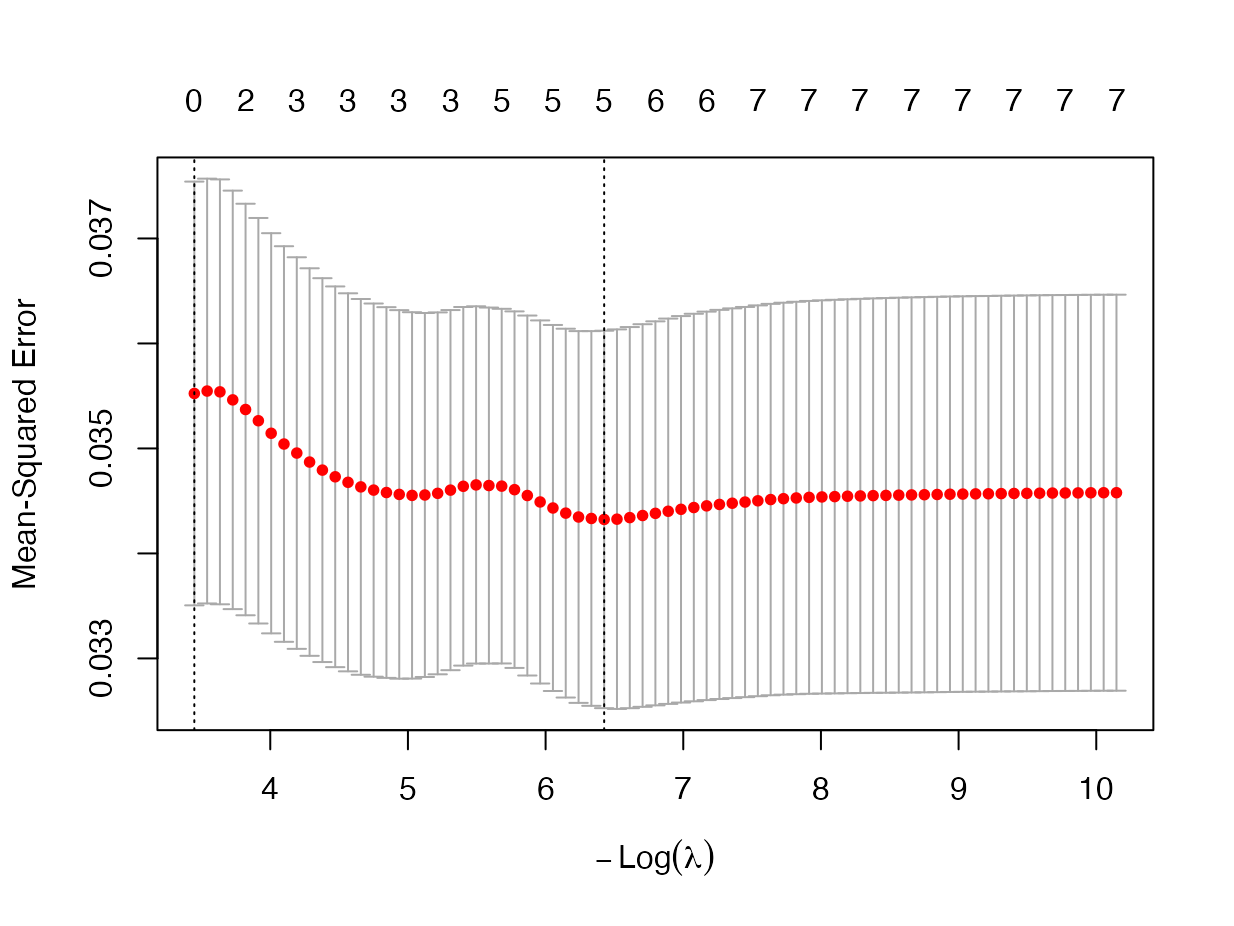

[1] "Selected lambda (min CV error): 0.00162"
[1] "--- LASSO Coefficients ---"


8 x 1 sparse Matrix of class "dgCMatrix"
                               s0
(Intercept)              5.71e-01
median_household_income  .       
median_home_value        2.37e-07
median_gross_rent       -2.11e-04
unemployment_rate       -1.47e-02
homeownership_rate       2.54e-03
poverty_rate             .       
bachelors_plus_rate      1.15e-03

In [23]:
## Part 8: LASSO Regression - NFL Win% ~ All Census Quality-of-Life Variables
lasso_vars <- c("median_household_income", "median_home_value", "median_gross_rent",
                "unemployment_rate", "homeownership_rate", "poverty_rate", "bachelors_plus_rate")

lasso_data <- combined_model_data %>%
  select(NFL_win_pct, all_of(lasso_vars)) %>%
  drop_na()

x <- as.matrix(lasso_data %>% select(all_of(lasso_vars)))
y <- lasso_data$NFL_win_pct

set.seed(42)
nfl_lasso_cv <- cv.glmnet(x, y, alpha = 1)

plot(nfl_lasso_cv)

nfl_lasso_model <- glmnet(x, y, alpha = 1, lambda = nfl_lasso_cv$lambda.min)

print(sprintf("Selected lambda (min CV error): %.5f", nfl_lasso_cv$lambda.min))
print("--- LASSO Coefficients ---")
coef(nfl_lasso_model)

In [24]:
combined_model_data$winning_szn <- ifelse(combined_model_data$NFL_win_pct <0.5, 0, 1)
str(combined_model_data)

tibble [246 × 13] (S3: tbl_df/tbl/data.frame)
 $ year                   : num [1:246] 2015 2015 2015 2015 2015 ...
 $ NFL_win_pct            : num [1:246] 0.75 0.5 0.938 0.375 0.75 0.438 0.25 0.75 0.625 0.563 ...
 $ team_count             : num [1:246] 4 2 2 5 2 4 4 4 1 3 ...
 $ median_household_income: num [1:246] 75389 50962 53076 61828 55501 ...
 $ median_home_value      : num [1:246] 368900 125000 166000 214400 153400 ...
 $ median_gross_rent      : num [1:246] 1236 726 863 984 751 ...
 $ unemployment_rate      : num [1:246] 7.04 7.09 9.35 9.48 7.53 ...
 $ homeownership_rate     : num [1:246] 61.4 66.1 65.8 64.7 66.4 ...
 $ poverty_rate           : num [1:246] 10.4 14.8 14.9 14 14.1 ...
 $ bachelors_plus_rate    : num [1:246] 44.6 30 32.2 35.5 31.1 ...
 $ violent_crime          : num [1:246] 4702 2887 5948 24663 2761 ...
 $ property_crime         : num [1:246] 15408 11176 33075 80395 16446 ...
 $ winning_szn            : num [1:246] 1 1 1 0 1 0 0 1 1 1 ...
